___

# Allgemeine Hinweise zur Klausur 01882 **Data Engineering für Data Science**
> **_NOTE:_**  *Bitte lesen Sie sich diese Hinweise vor der Bearbeitung der Klausur aufmerksam durch.*

- Die **Klausurdauer** beträgt **2 Stunden**.
- Bevor Sie mit der Bearbeitung der Klausuraufgaben beginnen, tragen Sie bitte Ihre(n) **Nachnamen**, Ihre(n) **Vornamen** und Ihre **Matrikelnummer** in die vorgesehenen Felder (oben) ein.
- Wie schon in den Übungsaufgaben erfolgt die Bearbeitung in zwei unterschiedliche Zell-Typen: In **Code-Zellen** sollen Sie (Python-)Code (bei Bedarf kommentiert) einfügen und ausführen. In **Raw-Zellen** erwarten wir eine Antwort in Textform.
- Sollten bestimmte Fakten aus Ihrer Sicht nicht eindeutig formuliert sein, so schreiben Sie Ihre Annahmen zur Lösung dazu.
- Denken Sie bei Plots an Titel, Achsenbeschriftung und bei Bedarf Legende.
- Es empfiehlt sich, das Notebook, bzw. das daraus generierte PDF in regelmäßigen Abständen zu sichern. So müssen Sie nicht bei Null anfangen, sollte es unerwartetere Weise zu Software-Problemen kommen.
- Diese Klausur ist eine sogenannte "Open-Book-Klausur", was bedeutet, dass Sie alle Vorlesungsunterlagen, etc. als Hilfsmittel verwenden dürfen. Es ist jedoch ausdrücklich **verboten**, dass Sie untereinander kommunizieren oder andere Personen zu Rate ziehen. 

___

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import iplantuml

# Marktanalyse
Ein fiktives Szenario: Die Geschwister Käfer besitzen bereits zwei Restaurants in der Stadt Pixhagen. Die beiden Restaurants laufen so gut, dass Sie überlegen, ob Sie ein neues Restaurant in Pixhagen eröffnen sollen und was für eine Art von Restaurant für die Pixhagener:innen von Interesse wäre. Für eine Marktanalyse schicken sie fünf Mitarbeiter:innen in die Stadt, um dort eine Umfrage durchzuführen. Am Tag nach der Umfrage werden Ihnen die Daten zur Verfügung gestellt. Dies ist der Inhalt der Klausur.

Folgende Dokumente stehen Ihnen zur Verfügung:
- *marktanalyse.csv* - Die Daten der Umfragen
- *informationen.pdf* - Informationen zu der fiktiven Stadt Pixhagen, den Geschwistern Käfer sowie der Umfrage und den Daten
- *umfrage.pdf* - Ein Muster des Umfragebogens, der den Mitarbeiter:innen zur Verfügung gestellt wurde
- *anmerkungen.pdf* - Die Anmerkungen zur Umfrage der fünf Mitarbeiter:innen

## Aufgabe 1 - Datenqualität (17 Punkte)
In der ersten Aufgabe geht es darum, sich mit den Daten vertraut zu machen und diese bzgl. ihrer Qualität zu analysieren.

### Aufgabe 1.1 Daten laden (1 Punkt)
*Laden Sie die Daten (`marktanalyse.csv`) in ein DataFrame namens `df`.*

In [24]:
# Ihre Lösung
df = pd.read_csv("marktanalyse.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Nr.         521 non-null    int64  
 1   MA          521 non-null    object 
 2   Geschlecht  521 non-null    object 
 3   Stadtteil   521 non-null    object 
 4   Ernaehrung  518 non-null    object 
 5   Einkommen   210 non-null    float64
 6   Budget      521 non-null    float64
 7   Besuche     521 non-null    int64  
 8   Interesse   521 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 36.8+ KB


### Aufgabe 1.2 Data Integrity (10 Punkte)
Machen Sie sich mit den Daten vertraut.

*Beurteilen Sie die Daten anhand der 5 Kriterien für **Data Integrity**, die Sie im Buch von McGregor in Kapitel 3 als **Important** kennengelernt haben.*

In [25]:
# Platz für Analysen
df.isna().sum()

Nr.             0
MA              0
Geschlecht      0
Stadtteil       0
Ernaehrung      3
Einkommen     311
Budget          0
Besuche         0
Interesse       0
dtype: int64

In [26]:
len(df)

521

### Aufgabe 1.3 Data Fit (4 Punkte)
*Beurteilen Sie, ob die Daten Ihrer Meinung nach geeignet sind, um eine Entscheidung über ein neues Restaurant zu treffen. Welche Informationen aus den Daten sind hilfreich und welche nicht? Welche weiteren Informationen wären ggf. notwendig?*

In [18]:
# Platz für Analysen
df[df["Besuche"] != 0]

,MA,Geschlecht,Stadtteil,Ernaehrung,Einkommen,Budget,Besuche,Interesse
Nr.,,,,,,,,
1,Sara Hofmann,m,Nord,vegetarisch,NaN,25.0,1,1
3,Sara Hofmann,m,Nord,vegetarisch,NaN,24.0,1,1
4,Sara Hofmann,m,Nord,vegetarisch,NaN,11.0,2,1
6,Sara Hofmann,f,Nord,vegetarisch,NaN,30.0,1,1
7,Sara Hofmann,f,Nord,vegetarisch,NaN,28.0,2,1
...,...,...,...,...,...,...,...,...
92,Layla Hawi,m,Nord,vegetarisch,0.0,37.0,1,1
95,Layla Hawi,w,West,frugan,0.0,38.0,1,0
96,Layla Hawi,m,Ost,vegetarisch,0.0,19.0,1,1


In [35]:
df[df["Interesse"] == 1].groupby("Ernaehrung").size()

Ernaehrung
alles          132
frugan           3
vegan           39
vegetarisch    175
dtype: int64

### Aufgabe 1.4 Repräsentativität (2 Punkte)
*Welche Informationen aus dem Datensatz können verwendet werden, um einzuschätzen, wie repräsentativ der Datensatz ist? Nennen Sie zudem **mindestens eine** weitere Information, die bisher nicht in den Daten enthalten ist, aber die hilfreich wäre, um die Repräsentativität besser beurteilen zu können.*

In [30]:
# Platz für Analysen
df.groupby("Geschlecht")["Nr."].count()

Geschlecht
Divers        3
Männlich    157
Weiblich    138
f            66
m           105
w            52
Name: Nr., dtype: int64

In [31]:
df["Geschlecht"] = df["Geschlecht"].map({"Divers": "d", "Männlich": "m", "Weiblich": "w", "f": "w"})

In [32]:
df.groupby("Geschlecht")["Nr."].count()

Geschlecht
d      3
m    157
w    204
Name: Nr., dtype: int64

In [33]:
df.groupby("Stadtteil")["Nr."].count()

Stadtteil
Nord    185
Ost      86
Süd     121
West    129
Name: Nr., dtype: int64

## Aufgabe 2 - Datenvorverarbeitung (22 Punkte)
Die zweite Aufgabe beschäftigt sich mit der Datenvorverarbeitung.

### Aufgabe 2.1 Plausibilitätschecks (6 Punkte)

Entsprechend der Anmerkungen der Mitarbeiter:innen sind verschiedene Plausibilitätschecks der Daten denkbar. Bei diesen Checks wird geprüft, ob sich die Aussagen der Mitarbeiter:innen in den Daten wiederspiegeln.

*Führen Sie drei Plausibilitätschecks Ihrer Wahl durch. Geben Sie bei jedem Check an, auf welche Aussage Sie sich beziehen und, ob der Check fehlgeschlagen ist oder nicht.*

In [23]:
# Ihre Lösung
df.loc[45]

,MA,Geschlecht,Stadtteil,Ernaehrung,Einkommen,Budget,Besuche,Interesse
Nr.,,,,,,,,
45,Sara Hofmann,f,Nord,vegetarisch,NaN,25.0,0,1
45,Oliver Gonzalez,Männlich,Ost,vegan,0.0,22.0,2,1
45,Karin Storch,Männlich,West,alles,NaN,27.0,1,0
45,Fadil Mebarek,Weiblich,Nord,vegetarisch,NaN,46.0,0,0
45,Layla Hawi,m,West,vegetarisch,0.0,36.0,1,0


### Aufgabe 2.2 Theoretische Überlegungen (2 + 2 Punkte)

Zunächst werden die Spalten `Besuche` und `Budget` betrachtet.

Die Spalte `Besuche` ist numerisch codiert. 

*Erläutern Sie (**nur beschreiben, kein Code erforderlich!**), inwiefern dies zu Problemen führen könnte. (2 Punkte)*

In der Spalte `Budget` gibt es einen Ausreißer:

<AxesSubplot: >

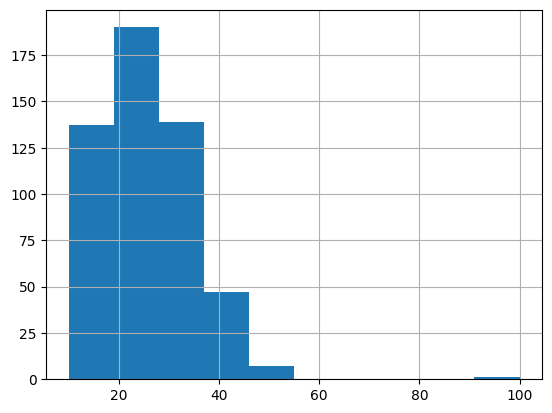

In [17]:
df.Budget.hist()

*Beschreiben Sie (**nur beschreiben, kein Code erforderlich!**), wie Sie mit diesem Ausreißer umgehen würden. (2 Punkte)*

### Aufgabe 2.3 Praktische Anwendung (12 Punkte)
Das Ziel der Geschwister Käfer ist es, wie oben beschrieben, herauszufinden, ob Interesse an einem neuen Restaurant vorhanden ist. Und falls Interesse da ist, sollen mithilfe der Umfrageergebnisse weitere Informationen ermittelt werden, welche Art von Restaurant am gefragtesten wäre. Für eine sinnvolle Analyse sind diverse Vorverarbeitungsschritte notwendig. 

*Führen Sie Vorverarbeitungsmaßnahmen durch, die Ihrer Meinung nach nötig sind, um die Qualität der Daten zu verbessern. Begründen Sie für jede Maßnahme Ihr Vorgehen.*


>> **Achtung**: *Da die Spalten `Besuche` und `Budget` bereits in den vorherigen Aufgaben theortetisch diskutiert wurden, sind sie deshalb aus Zeitgründen für diese Aufgabe nicht relevant. Zudem ist eine **Umbenennung** von Spalten aus Zeitgründen ebenfalls nicht notwendig!*

In [ ]:
# Ihre Lösung

## Aufgabe 3 - Datenanalyse (16 Punkte)
In dieser Aufgabe werden Analysen auf den Daten ausgeführt.

### Aufgabe 3.1 (6 Punkte)
*Ermitteln Sie folgende Informationen:*
- Wie ist das durchschnittliche Interesse nach Ernaerhung? Bei welcher Gruppe ist das Interesse am höchsten und bei welcher am niedrigsten? (2 Punkte)
- Aus welchem Stadtteil stammen die meisten der befragten Personen?  (2 Punkte)
- Welches der beiden bereits existierenden Restaurant wurde bisher am häufigsten von Bewohner:innen der Weststadt besucht?  (2 Punkte)

*Interpretieren Sie die Aussage Ihres Codes, indem Sie die Antwort auf die jeweilige Frage in die dafür vorgesehene Raw-Zelle schreiben. Schätzen Sie dabei für jede Frage die Aussagekraft der Ergebnisse ein.*

In [ ]:
# Wie ist das durchschnittliche Interesse nach Ernaerhung? (nur Code)
# Bei welcher Gruppe ist das Interesse am höchsten und bei welcher am niedrigsten? (Antwort in Raw-Zelle)

In [ ]:
# Aus welchem Stadtteil stammen die meisten der befragten Personen? 

In [ ]:
# Welches der beiden bereits existierenden Restaurant wurde bisher am häufigsten von Bewohner:innen der Weststadt besucht?

### Aufgabe 3.2 (4 Punkte)
Gibt es einen Unterschied in der Ernährungsweise je nach Stadtteil? 

*Beantworten Sie die Frage mithilfe von Kreisdiagrammen. Denken Sie dabei an Titel und Legende sowie die Interpretation des Diagramms.*

In [ ]:
# Ihre Lösung

### Aufgabe 3.3 (4 Punkte)
Gibt es bzgl. des durchschnittlichen Interesses an einem neuen Restaurant einen großen Unterschied in Abhängigkeit der Stadtteile?

*Beantworten Sie die Frage mithilfe eines Säulendiagramms. Denken Sie dabei an Titel und Achsenbeschriftung sowie die Interpretation des Diagramms.*

In [ ]:
# Ihre Lösung

### Aufgabe 3.4 (2 Punkte)
*Entsprechend Ihrer Analysen: Wenn ein neues Restaurant eröffnet werden soll, welchen Stadtteil würden Sie empfehlen und welche Hinweise würden Sie für die Ausrichtung der Speisekarte entsprechend der Ernährungsweise geben? Nehmen Sie für diese Aufgabe an, dass Sie eine Entscheidung treffen müssen und es aus Zeit- und Kostengründen keine Option ist, weitere Informationen (z.B. durch eine erneute Umfrage) einzuholen.*

## Aufgabe 4 - Big Data Analysis (15 Punkte)
In diesem Aufgabenbereich geht es um Hadoop und Spark.

### Aufgabe 4.1 Hadoop Map Reduce vs. Spark (2 + 1 Punkte)
*Beschreiben Sie die Unterschiede zwischen der Verarbeitung der Tasks von Hadoop MapReduce und von Spark. (2 Punkte)*

*Welche Vorteile ergeben sich daraus bei der Arbeit mit Spark? (1 Punkt)*

### Aufgabe 4.2 Eigenschaften RDDs (8 Punkte)
Nennen Sie vier der fünf wichtigsten Eigenschaften von RDDs. Beschreiben Sie für jede Eigenschaft mit einem kurzen Satz, warum sie von Bedeutung ist.

### Aufgabe 4.3 Ressourcenvebrauch (4 Punkte)
Gegeben sei folgender Auszug aus der Datei `spark-defaults.conf`:

```
spark.executor.instances 3
spark.executor.memory 1G
spark.executor.cores 2
spark.executor.memoryOverhead 512M

spark.yarn.am.cores 1
spark.yarn.am.memory 2G
spark.yarn.am.memoryOverhead 512M

spark.dynamicAllocation.enabled false
```

Ein pyspark-Shell wird mit folgendem Aufruf gestartet:
`pyspark --master yarn`

Gehen Sie davon aus, dass im Cluster genügend freie Ressourcen zur Verfügung stehen, um die Anfragen des Application Masters zu erfüllen.

*Berechnen Sie den Ressourcen-Verbrauch (Memory und Cores) der Spark-Anwendung. Geben Sie dabei Ihren Rechenweg an.*

## Aufgabe 5 - Modellierung, NoSQL (25 Punkte)

### Aufgabe 5.1 (2 Punkte)

Beschreiben Sie Anwendungseigenschaften bzw. Charakteristika, die eher für die Verwendung eines dokumentorientierten bzw. spaltenorientierten Datenbanksystems sprechen.

### Aufgabe 5.2 (2 Punkte)

Embedded vs. referentielle Modellierung bei dokumentorientierten Datenbanksystemen wie MongoDB.

Sie möchten aus Eigenschaften der Anwendung bzw. der Abfragen schlussfolgern, welche Art der Modellierung (embedded oder referenziell) Sie wählen sollen. Geben Sie Modellierungsrichtlinien bzw. Anwendungscharakteristika an, die einen starken Einfluss auf die Auswahl der Modellierung haben.

### Aufgabe 5.3 (21 Punkte)

In einem dokumentenorientierten NoSQL-Datenbanksystem sollen Kunden, Produkte und Bestellungen gespeichert werden. Dabei können pro Bestellung **mehrere Produkte in unterschiedlicher Anzahl** bestellt werden. Außerdem können Kunden Reviews zu den bestellten Produkten abgeben.


Geplante Abfragen:

- Es können neue Produkte hinzugefügt werden.
- Die Preise der Produkte können verändert werden.
- Produkte können entfernt werden.
- Neue Kunde können angelegt werden.
- Es kann nach Produkten gesucht werden. Zu den Produkten werden neben den Produktinformationen ebenfalls die 10 neuesten Reviews angezeigt.
- Ein Kunde kann eine neue Bestellung aufgeben.
- Ein Kunde kann Reviews über gekaufte Produkte schreiben.
- Ein Kunde kann sich seine  Bestellungen innerhalb eines bestimmten Zeitraums anzeigen lassen. Das Gleiche gilt für Reviews.


1. Erstellen Sie zunächst ein plattformunabhängiges (konzeptionelles) Modell (dieses Modell enthält noch keine Fremdschlüssel, Einbettungen und Datentypen). Modellieren Sie außerdem folgende Attribute: Kunden haben einen Namen und Vornamen. Bestellungen haben ein Datum. Produkte haben einen Titel, einen Preis und eine Beschreibung. Reviews enthalten den Text und ein Datum.
2. Skizzieren Sie anschließend ein geeignetes Datenmodell für die Speicherung in einem dokumentenorientierten Datenbanksystem. Begründen Sie ihre Entscheidungen für Referenzierungen, Einbettungen und redundante Speicherung bzw. Einbettung. Heben Sie redundante- und Fremdschlüssel-Attribute farblich hervor.

In [ ]:
%%plantuml --jar

@startuml

hide circle
hide members
show fields


@enduml

In [ ]:
%%plantuml --jar

@startuml

hide circle
hide members
show fields


@enduml

## Aufgabe 6 - Technologien für Big Data (5 Punkte)

### Aufgabe 6.1 (2 Punkte)
Warum eignen sich spaltenorientierte Datenbanksysteme sehr gut für analytische Anwendung wie beispielsweise Data Warehouses?

### Aufgabe 6.2 (1 Punkt)
In einer Tabelle `Verkauf` mit Verkaufsdaten ist jeder Datensatz (jede Zeile) im Mittel 100 Bytes lang. Das Attribut `Filiale` belegt 5 Bytes. Wieviel Prozent der Daten müssen bei einer spaltenorientierten Speicherung im Vergleich zu einer zeilenorientierten Speicherung gelesen werden, wenn die folgende SQL-Query ausgeführt wird?

`SELECT Filiale, COUNT(*) FROM Verkauf GROUP BY Filiale;`

### Aufgabe 6.3 (2 Punkte)
Angenommen, Sie verwenden in einem Cluster mit *n* Servern für die Zuordnung der Daten mit Key *k* die Hashfunktion *k mod n*. Welche Probleme würden in diesem Szenario auftreten?